# Parallelized sweep of get_int_aligned_trajectory `jerk_threshold`

`get_int_aligned_trajectory` interpolates + physically filters each device
stream before the DTW match. This notebook sweeps its `jerk_threshold`
parameter while leaving the other filter parameters at their defaults.

Because `jerk_threshold` changes the INPUT to the DTW (it filters the
interpolated trajectory before matching), every value needs a full DTW build —
there is no "match once, reprocess many" shortcut like the DTW outlier
time-threshold sweep. We therefore monkeypatch
`emr.get_int_aligned_trajectory` inside each worker so the existing
`emr.ref_dtw_gt_with_ends_general` runs the complete build with the swept
parameter, and fan every `(value, timeline, section)` combination out across
the joblib loky process pool.

In [1]:
# for reading and validating data
import emeval.input.spec_details as eisd
import emeval.input.phone_view as eipv
import emeval.input.eval_view as eiev

# Metrics helpers
import emeval.metrics.dist_calculations as emd
import emeval.metrics.reference_trajectory as emr
import emeval.metrics.DTW as dtw

# For computation
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely as shp
import matplotlib.pyplot as plt
import arrow
import os
import copy
import pickle
import itertools
from joblib import Parallel, delayed
import importlib
importlib.reload(emr)

/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


<module 'emeval.metrics.reference_trajectory' from '/kfs2/projects/teta/kgovil/mobilitynet-analysis-scripts/emeval/metrics/reference_trajectory.py'>

In [2]:
DATASTORE_LOC = "bin/data"
AUTHOR_EMAIL = "shankari@eecs.berkeley.edu"
sd_la = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "unimodal_trip_car_bike_mtv_la")
sd_sj = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "car_scooter_brex_san_jose")
sd_ucb = eisd.FileSpecDetails(DATASTORE_LOC, AUTHOR_EMAIL, "train_bus_ebike_mtv_ucb")

pv_la = eipv.PhoneView(sd_la)
pv_sj = eipv.PhoneView(sd_sj)
pv_ucb = eipv.PhoneView(sd_ucb)
pvs = [pv_la, pv_sj, pv_ucb]

After iterating over 1 entries, entry found
Found spec = Round trip car and bike trip in the South Bay
Evaluation ran from 2019-07-20T00:00:00-07:00 -> 2020-04-29T17:00:00-07:00
After iterating over 1 entries, entry found
Found spec = Multi-modal car scooter BREX trip to San Jose
Evaluation ran from 2019-07-20T00:00:00-07:00 -> 2020-04-29T17:00:00-07:00
After iterating over 1 entries, entry found
Found spec = Multimodal multi-train, multi-bus, ebike trip to UC Berkeley
Evaluation ran from 2019-07-16T00:00:00-07:00 -> 2020-04-30T00:00:00-07:00
-------------------- About to read transitions from server --------------------
Reading data for android phones
Loading transitions for phone ucb-sdb-android-1
Loading transitions for phone ucb-sdb-android-2
Loading transitions for phone ucb-sdb-android-3
Loading transitions for phone ucb-sdb-android-4
Reading data for ios phones
Loading transitions for phone ucb-sdb-ios-1
Loading transitions for phone ucb-sdb-ios-2
Loading transitions for phone u

Loading transitions for phone ucb-sdb-ios-4
-------------------- About to fill calibration ranges --------------------
Processing data for android phones
Processing transitions for phone ucb-sdb-android-1
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-2
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-3
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-android-4
Filtered 86 total -> 0 calibration transitions 
Processing data for ios phones
Processing transitions for phone ucb-sdb-ios-1
Filtered 1114 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-2
Filtered 88 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-3
Filtered 86 total -> 0 calibration transitions 
Processing transitions for phone ucb-sdb-ios-4
Filtered 86 total -> 0 calibration transitions 
Processing data for android phones
--

Processing data for ios phones


-------------------- About to fill in location information --------------------
Processing data for android phones
Processing data for ios phones
Processing data for android phones


Processing data for ios phones


...

Filling label ucb-sdb-ios-1 for OS ios


Filling label ucb-sdb-ios-2 for OS ios


Filling label ucb-sdb-ios-3 for OS ios


Filling label ucb-sdb-ios-4 for OS ios


-------------------- Done populating information from server --------------------


In [3]:
def get_reference_trajectory_input_tree(pv):
    ref_tree = {}

    for phone_os, phone_map in pv.map().items():
        for phone_label, phone_detail_map in phone_map.items():
            for (r_idx, r) in enumerate(phone_detail_map["evaluation_ranges"]):
                if r["eval_role_base"] != "accuracy_control":
                    continue
                for (tr_idx, tr) in enumerate(r["evaluation_trip_ranges"]):
                    for (sr_idx, sr) in enumerate(tr["evaluation_section_ranges"]):
                        section_gt_leg = pv.spec_details.get_ground_truth_for_leg(tr["trip_id_base"], sr["trip_id_base"], sr["start_ts"], sr["end_ts"])
                        section_gt_shapes = gpd.GeoSeries(eisd.SpecDetails.get_shapes_for_leg(section_gt_leg))
                        if len(section_gt_shapes) == 1:
                            print("No ground truth route for %s %s, must be polygon, skipping..." % (tr["trip_id_base"], sr["trip_id_base"]))
                            assert section_gt_leg["type"] != "TRAVEL", "For %s, %s, %s, %s, %s found type %s" % (phone_os, phone_label, r_idx, tr_idx, sr_idx, section_gt_leg["type"])
                            continue
                        if len(sr['location_df']) == 0:
                            print("No sensed locations found, role = %s skipping..." % (r["eval_role_base"]))
                            continue

                        print("Processing travel leg %s, %s, %s, %s, %s" %
                              (phone_os, phone_label, r["eval_role_base"], tr["trip_id_base"], sr["trip_id_base"]))
                        sec_name = tr["trip_id_base"] + "/" + sr["trip_id_base"] + "_" + str(r_idx)
                        if sec_name not in ref_tree:
                            ref_tree[sec_name] = {
                                "trip_id": tr["trip_id_base"],
                                "section_id": sr["trip_id_base"],
                                "run": r_idx,
                                "ground_truth": {
                                    "leg": section_gt_leg
                                }
                            }

                        assert sec_name in ref_tree
                        e = ref_tree[sec_name]
                        section_measured_points = sr["location_df"]
                        if "temporal_control" not in e:
                            e["temporal_control"] = {}
                            e["start_ts"] = sr["start_ts"]
                            e["end_ts"] = sr["end_ts"]
                        e["temporal_control"][phone_os] = sr
    return ref_tree

## Build the input trees once, then sweep `jerk_threshold`

The ground-truth / location loading is expensive, so we do it serially once per
timeline and pre-serialize each section's base entry. The sweep itself fans out
every `(jerk_threshold, timeline, section)` combination across the joblib loky
process pool.

Each worker temporarily replaces `emr.get_int_aligned_trajectory` with a wrapper
that injects the swept `jerk_threshold` and then calls the unmodified
`emr.ref_dtw_gt_with_ends_general`, so the full DTW build runs with the new
filter. The patch is process-local (loky uses separate processes) and is
restored after every task.

In [4]:
# Python 3.11 still has the GIL, so a ThreadPoolExecutor gains nothing for this
# CPU-bound work. Use joblib's process-based parallelism (loky backend) so the
# builders actually run concurrently across cores.
N_JOBS = 100

# The parameter being swept and the values to try. 5 is the historical default.
PARAM_NAME = "jerk_threshold"
PARAM_VALUES = [10, 11, 12, 13, 14, 15]

# Each entry is (label, kwargs-to-inject-into-get_int_aligned_trajectory).
PARAM_SETTINGS = [(v, {PARAM_NAME: v}) for v in PARAM_VALUES]

In [5]:
# Build the (parameter-independent) input trees once per timeline.
input_trees = {}      # timeline_id -> {sec_name: base_entry}
timeline_tz = {}      # timeline_id -> tz
for pv in pvs:
    input_trees[pv.spec_details.CURR_SPEC_ID] = get_reference_trajectory_input_tree(pv)
    timeline_tz[pv.spec_details.CURR_SPEC_ID] = pv.spec_details.eval_tz

# Pre-serialize every section's base_entry exactly once. base_entry holds the
# raw android/ios location dataframes and is expensive to pickle, so doing it
# here means the same bytes are reused for every parameter task that operates on
# that section instead of joblib re-pickling the live object once per task.
serialized_entries = {}   # timeline_id -> {sec_name: pickled base_entry bytes}
for timeline, tree_in in input_trees.items():
    serialized_entries[timeline] = {
        sec_name: pickle.dumps(base_entry, protocol=pickle.HIGHEST_PROTOCOL)
        for sec_name, base_entry in tree_in.items()
    }

No ground truth route for suburb_city_driving_weekend walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_city_driving_weekend, suburb_city_driving_weekend
No ground truth route for suburb_city_driving_weekend walk_end, must be polygon, skipping...
No ground truth route for suburb_bicycling walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_bicycling, suburb_bicycling
No ground truth route for suburb_bicycling walk_end, must be polygon, skipping...
No ground truth route for suburb_city_driving_weekend walk_start, must be polygon, skipping...
Processing travel leg android, ucb-sdb-android-1, accuracy_control, suburb_city_driving_weekend, suburb_city_driving_weekend
No ground truth route for suburb_city_driving_weekend walk_end, must be polygon, skipping...
No ground truth route for suburb_bicycling walk_start, must be polygon, skipping...
Processing travel leg

Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, commuter_rail_with_tunnels
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, berkeley_to_mtv_SF_express_bus, inner_suburb_downtown_walk
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, mtv_to_berkeley_sf_bart, walk_to_caltrain
No ground truth route for mtv_to_berkeley_sf_bart wait_for_commuter_rail_aboveground, must be polygon, skipping...
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, mtv_to_berkeley_sf_bart, commuter_rail_aboveground
No ground truth route for mtv_to_berkeley_sf_bart tt_commuter_rail_aboveground_subway_underground, must be polygon, skipping...
No ground truth route for mtv_to_berkeley_sf_bart wait_for_subway_underground, must be polygon, skipping...
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, mtv_to_berkeley_sf_bart, subway_underground
Processing travel leg ios, ucb-sdb-ios-1, accuracy_control, mtv_to_berkeley_sf_bart, walk_to_b

In [6]:
# The sweep changes the INPUT to the DTW, so unlike the time-threshold sweep we
# cannot cache a single match and reprocess it -- every parameter value needs a
# full DTW build. ref_dtw_gt_with_ends_general now forwards the filter
# parameters straight through to get_int_aligned_trajectory, so we just pass the
# swept value in directly.
import traceback


def stats_for_ref(ref_df, e):
    """The same per-reference stats that emr.ref_and_stats computes."""
    emr.speed_acceleration_jerk(ref_df)
    stats = {
        "coverage_density": emr.coverage_density(ref_df, e),
        "coverage_time": emr.coverage_time(ref_df, e),
        "coverage_max_gap": emr.coverage_max_gap(ref_df, e),
        "max_jerk": emr.max_jerk(ref_df, e),
        "max_acceleration": emr.max_acceleration(ref_df, e),
        "max_speed": emr.max_speed(ref_df, e),
        "median_jerk": emr.median_jerk(ref_df, e),
        "mean_median_jerk_ratio": emr.mean_median_jerk_ratio(ref_df, e),
    }
    try:
        stats["gt_error"] = emd.dist_using_projection_adjusted(ref_df, e["ground_truth"]["linestring"])
    except Exception as exp_gt:
        print("Found exception %s while computing gt_error" % exp_gt)
        stats["gt_error"] = np.nan
    return stats


def process_for_params(param_label, param_kwargs, timeline, sec_name, base_entry_bytes, tz):
    e = pickle.loads(base_entry_bytes)
    try:
        emr.fill_gt_linestring(e)
        ref_df = emr.ref_dtw_gt_with_ends_general(e, tz=tz, **param_kwargs)
        if ref_df is None or len(ref_df) == 0:
            return {"__error__": "empty ref_df", PARAM_NAME: param_label,
                    "timeline": timeline, "sec_name": sec_name}
        stats = stats_for_ref(ref_df, e)
    except Exception as exp:
        # Return the failure (with traceback) instead of None so we can see why
        # a task failed -- prints inside loky workers are easy to miss.
        return {"__error__": "%s: %s" % (type(exp).__name__, exp),
                "__traceback__": traceback.format_exc(),
                PARAM_NAME: param_label, "timeline": timeline, "sec_name": sec_name}

    row = {
        PARAM_NAME: param_label,
        "timeline": timeline,
        "sec_name": sec_name,
        "n_points": len(ref_df),
    }
    row.update(stats)
    return row


# Fan out every (parameter, timeline, section) combination.
sweep_tasks = []
for param_label, param_kwargs in PARAM_SETTINGS:
    for timeline, tree_in in input_trees.items():
        for sec_name in tree_in:
            sweep_tasks.append((param_label, param_kwargs, timeline, sec_name,
                                serialized_entries[timeline][sec_name],
                                timeline_tz[timeline]))

print("Processing %d %s x segment combinations on %d processes" %
      (len(sweep_tasks), PARAM_NAME, N_JOBS))
sweep_results = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(process_for_params)(*t) for t in sweep_tasks)

# Split successes from failures so an all-failed run reports *why* instead of
# producing an empty DataFrame that blows up on the later groupby.
sweep_rows = [r for r in sweep_results if r is not None and "__error__" not in r]
sweep_errors = [r for r in sweep_results if r is not None and "__error__" in r]
sweep_df = pd.DataFrame(sweep_rows)
print("Collected %d of %d reference stats (%d failed)" %
      (len(sweep_df), len(sweep_tasks), len(sweep_errors)))
if len(sweep_df) == 0 and sweep_errors:
    print("\nAll tasks failed. First failure traceback:\n")
    print(sweep_errors[0].get("__traceback__", sweep_errors[0]["__error__"]))
sweep_df.head()

Processing 1176 jerk_threshold x segment combinations on 100 processes


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.


/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kgovil/miniconda-23.1.0/envs/emissioneval/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is 

...

After filtering against polygons 2, 78 -> 74
After filtering against polygons 2, 78 -> 74
After filtering against polygons 2, 78 -> 74
After filtering against polygons 2, 78 -> 74
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 32 -> 27
After filtering against polygons 2, 83 -> 74
After filtering against polygons 2, 83 -> 74
After filtering against polygons 2, 83 -> 74
After filtering against polygons 2, 83 -> 74
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filt

After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 89 -> 81
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 624 -> 621
After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 78 -> 67
After filtering against polygons 2, 701 -> 698
After filtering against polygons 2, 7

Collected 1176 of 1176 reference stats (0 failed)


[Parallel(n_jobs=100)]: Done 1176 out of 1176 | elapsed: 49.8min finished


,jerk_threshold,timeline,sec_name,n_points,coverage_density,coverage_time,coverage_max_gap,max_jerk,max_acceleration,max_speed,median_jerk,mean_median_jerk_ratio,gt_error
0,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,817,1.098848,0.970399,0.041178,397555.341657,9734.073833,244.473348,20.002940,0.015761,4.738408e-10
1,10,unimodal_trip_car_bike_mtv_la,suburb_bicycling/suburb_bicycling_0,1270,1.090674,0.957836,0.063393,180151.031645,525.952512,25.113352,4.821004,0.014069,8.120676e-10
2,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,702,1.120415,0.959937,0.033097,50502.658261,517.380603,52.448589,8.214360,0.074576,4.738408e-10
3,10,unimodal_trip_car_bike_mtv_la,suburb_bicycling/suburb_bicycling_1,1333,1.086544,0.959995,0.082033,52215.309393,366.685119,24.836019,3.467245,0.025872,8.120676e-10
4,10,unimodal_trip_car_bike_mtv_la,suburb_city_driving_weekend/suburb_city_drivin...,709,1.120363,0.942197,0.055702,7725.696321,215.085282,50.248764,11.197626,0.202191,4.738408e-10


In [7]:
# Persist the raw per-section sweep so it can be reloaded without rebuilding.
sweep_df.to_csv("get_int_aligned_jerk_sweep.csv", index=False)

## Aggregate across sections per `jerk_threshold`

In [8]:
assert len(sweep_df) > 0, (
    "sweep_df is empty -- every task failed, so there is nothing to aggregate. "
    "Check the failure traceback printed by the sweep cell above.")

agg_metrics = [m for m in ["gt_error", "coverage_density", "coverage_time",
                           "coverage_max_gap", "max_jerk", "max_acceleration",
                           "max_speed", "median_jerk", "mean_median_jerk_ratio",
                           "n_points"]
               if m in sweep_df.columns]
param_summary = sweep_df.groupby(PARAM_NAME)[agg_metrics].mean()
param_summary["n_sections"] = sweep_df.groupby(PARAM_NAME).size()
param_summary

,gt_error,coverage_density,coverage_time,coverage_max_gap,max_jerk,max_acceleration,max_speed,median_jerk,mean_median_jerk_ratio,n_points,n_sections
jerk_threshold,,,,,,,,,,,
10,7.472721e-10,1.125837,0.968410,0.060380,5.427161e+11,1.685395e+07,1539.886976,17.413446,0.024048,1568.107143,196
11,7.472721e-10,1.125837,0.968382,0.060384,1.602262e+11,4.459247e+06,1062.471263,17.181375,0.023870,1568.107143,196
12,7.472721e-10,1.125837,0.968360,0.060441,1.602248e+11,4.459032e+06,1061.453883,16.946655,0.023975,1568.107143,196
13,7.472721e-10,1.125837,0.968337,0.060463,1.838272e+11,4.473112e+06,1054.209268,16.666487,0.024608,1568.107143,196
14,7.472721e-10,1.125842,0.968341,0.060468,1.838457e+11,4.481763e+06,1057.692021,16.583429,0.024617,1568.112245,196
15,7.472721e-10,1.125842,0.968305,0.060507,1.838458e+11,4.481896e+06,1058.260405,16.409104,0.024451,1568.112245,196


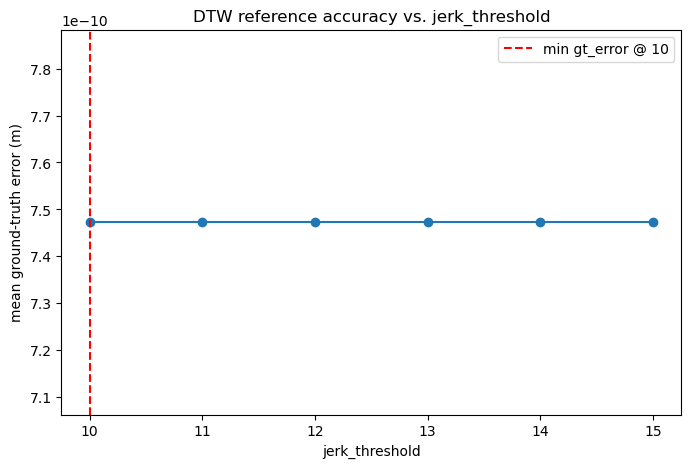

In [9]:
# Plot the mean ground-truth error against the swept parameter; the value that
# minimizes gt_error is the best candidate.
if "gt_error" in param_summary.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(param_summary.index, param_summary["gt_error"], marker="o")
    best = param_summary["gt_error"].idxmin()
    ax.axvline(best, color="red", linestyle="--", label="min gt_error @ %s" % best)
    ax.set_xlabel(PARAM_NAME)
    ax.set_ylabel("mean ground-truth error (m)")
    ax.set_title("DTW reference accuracy vs. %s" % PARAM_NAME)
    ax.legend()
    fig

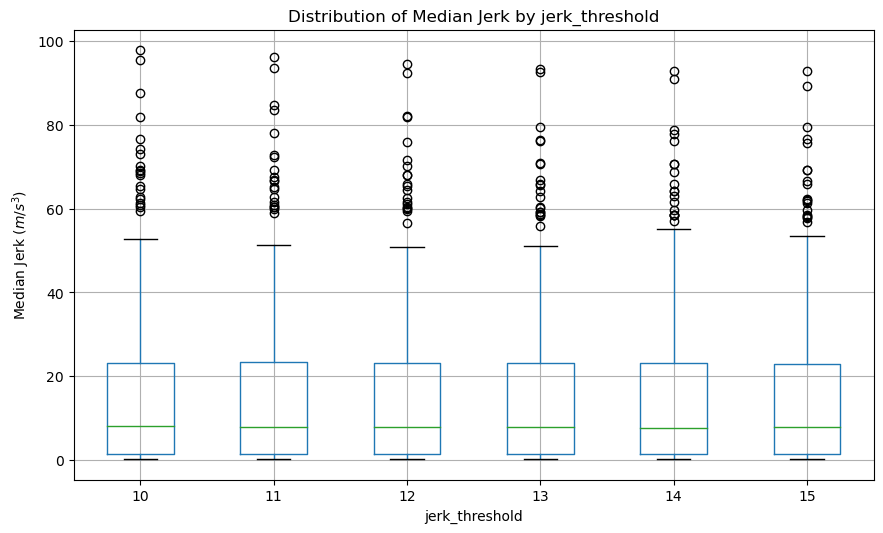

In [10]:
# Plot box plots of median jerk for every parameter value to see how much noise
# remains in the trajectories at different settings.
if "median_jerk" in sweep_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    # We drop any NaNs/Infs to ensure the boxplot renders properly
    clean_df = sweep_df[np.isfinite(sweep_df["median_jerk"])]
    clean_df.boxplot(column="median_jerk", by=PARAM_NAME, ax=ax, grid=True)
    ax.set_xlabel(PARAM_NAME)
    ax.set_ylabel("Median Jerk ($m/s^3$)")
    ax.set_title("Distribution of Median Jerk by %s" % PARAM_NAME)
    plt.suptitle("")  # Clear the automatic pandas subtitle
    fig